### ***Fraud Detection using Machine Learning Models***

## **SECTION 1- DATA ANALYSIS**

### Initial Setup and Library Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [9]:
df = pd.read_excel('/content/creditcard_1.xlsx', engine='openpyxl')


### Load the Dataset

In [10]:
print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Data Overview and Initial Inspection

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  int64  
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### Check for Missing Values

In [12]:
print("\nMissing values:\n", df.isnull().sum())



Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


### Check for Duplicate Rows

In [13]:
print("\nDuplicates:", df.duplicated().sum())


Duplicates: 1081


### Descriptive Statistics

In [14]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.205498e-16,-2.406306e-15,...,1.656562e-16,-3.568593e-16,2.610582e-16,4.473066e-15,5.213180e-16,1.683537e-15,-3.659966e-16,-1.223710e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Target Variable Distribution (Class)

Class
0    284315
1       492
Name: count, dtype: int64


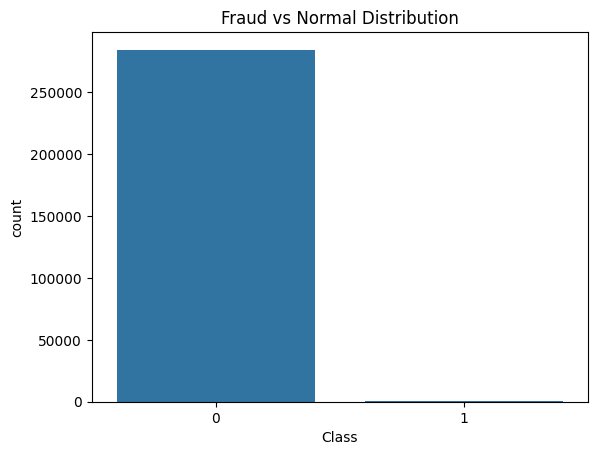

In [15]:
target = "Class"

print(df[target].value_counts())

sns.countplot(x=df[target])
plt.title("Fraud vs Normal Distribution")
plt.show()

### Feature Distributions

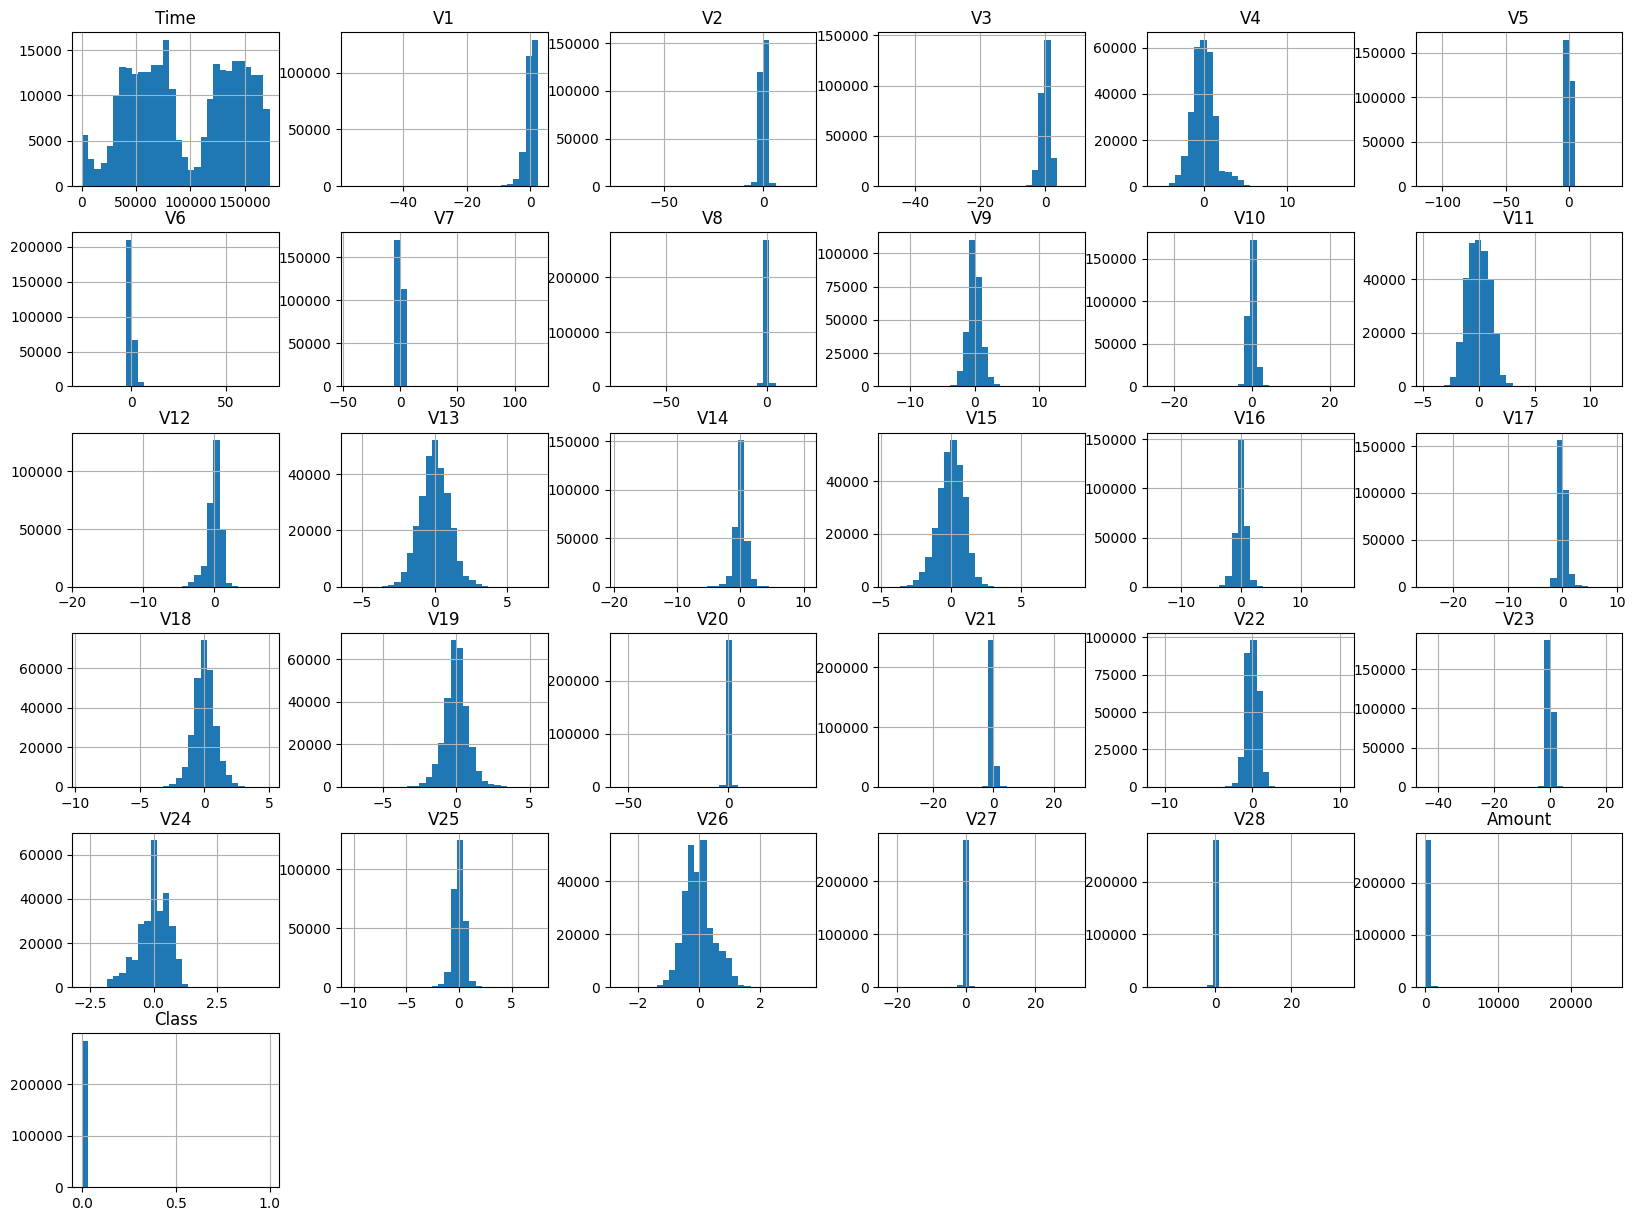

In [16]:
df.hist(figsize=(20,15), bins=30)
plt.show()

### Transaction Amount vs. Fraud (Box Plot)

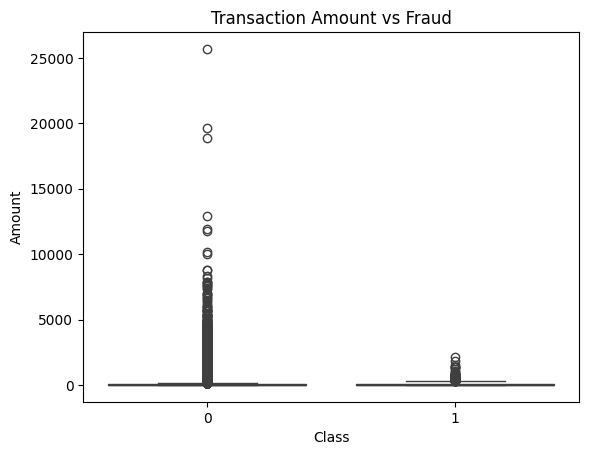

In [17]:
plt.figure()
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

### Correlation Heatmap

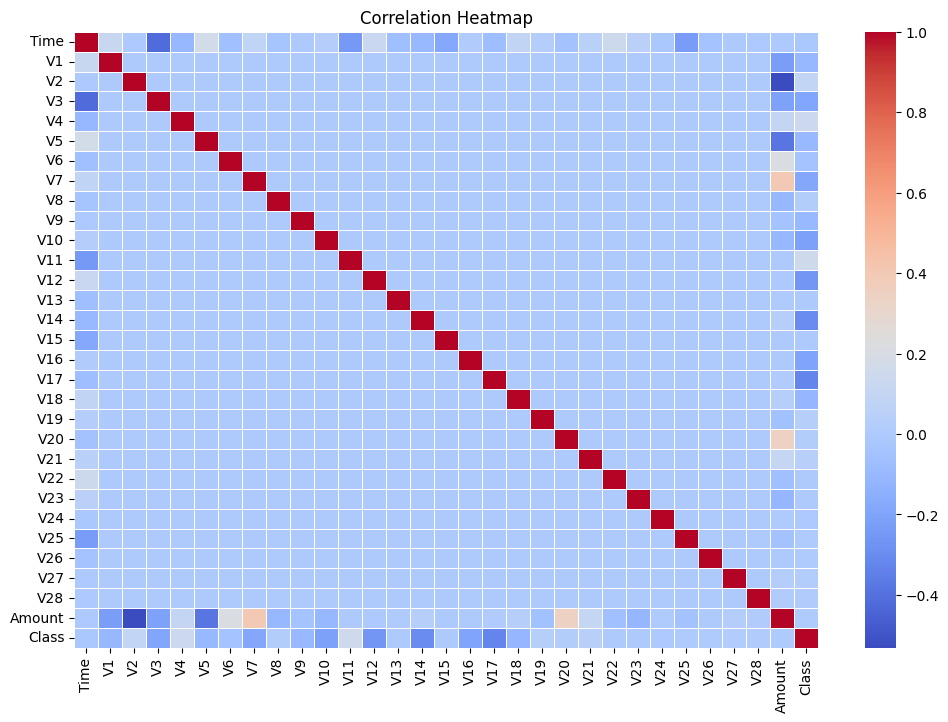

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## **SECTION 2-DATA PREPROCESSING**

### Remove Duplicate Rows

In [19]:
df = df.drop_duplicates()

### Separate Features (X) and Target (y)

In [20]:
X = df.drop(columns=[target])
y = df[target]

### Train-Test Split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Feature Scaling with RobustScaler

In [22]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Handling Imbalance with SMOTE (XGBoost specific preprocessing)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

# Re-split and scale to ensure original (pre-SMOTE) data is used
X_train_original, X_test, y_train_original, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_original)
X_test = scaler.transform(X_test)
y_train = y_train_original

smote = SMOTE(
    sampling_strategy=1.0,
    random_state=42,
    k_neighbors=5
)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train).value_counts())

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


### Outlier Detection for 'Amount' Feature (IQR Method)

In [24]:
# Detect outliers in Amount feature using IQR
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers
outliers = df[
    (df['Amount'] < lower_bound) |
    (df['Amount'] > upper_bound)
]

print("Number of detected outliers:", len(outliers))


Number of detected outliers: 31685


### Verify Data Shapes and Class Balance After Preprocessing

In [25]:
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

print("\nTrain Class Balance:")
print(pd.Series(y_train).value_counts())

print("\nTest Class Balance:")
print(pd.Series(y_test).value_counts())

Train Shape: (453204, 30)
Test Shape: (56746, 30)

Train Class Balance:
Class
0    226602
1    226602
Name: count, dtype: int64

Test Class Balance:
Class
0    56651
1       95
Name: count, dtype: int64


# **SECTION 3 - MODEL TRAINING AND EVALUATION**

## **XGBoost**

### XGBoost Classifier Setup

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

from xgboost import XGBClassifier

import seaborn as sns
import matplotlib.pyplot as plt

### Calculate Scale Position Weight for XGBoost

In [ ]:
ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])

print("Scale Pos Weight:", ratio)

Scale Pos Weight: 1.0


### Initialize XGBoost Model

In [ ]:

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=1
)

### Define Hyperparameter Grid for XGBoost

In [ ]:
param_grid = {
    "max_depth": [3,4,5],
    "learning_rate": [0.03,0.05,0.1],
    "n_estimators": [150,250,350],
    "subsample": [0.8,1.0],
    "colsample_bytree": [0.8,1.0]
}

### Perform Grid Search for XGBoost Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid

# Original parameter grid
param_grid = {
    "max_depth": [3,4,5],
    "learning_rate": [0.03,0.05,0.1],
    "n_estimators": [150,250,350],
    "subsample": [0.8,1.0],
    "colsample_bytree": [0.8,1.0]
}

# Take only first 25 parameter combinations and wrap single values in lists
param_list_raw = list(ParameterGrid(param_grid))[:25]
param_list_for_gridsearch = []
for combo in param_list_raw:
    wrapped_combo = {k: [v] for k, v in combo.items()}
    param_list_for_gridsearch.append(wrapped_combo)

# Grid Search
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_list_for_gridsearch, # Use the corrected list
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Train
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

print("Best Params:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)


Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Params:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 350, 'subsample': 0.8}

Best CV Score:
0.9974123380787573


### Optimize Prediction Threshold for XGBoost

In [ ]:
# Threshold Optimization

probs = best_model.predict_proba(X_test)[:,1]

best_f1 = 0
best_threshold = 0.50

for th in np.arange(0.30,0.91,0.05):

    preds = (probs > th).astype(int)

    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th

print("Best Threshold:", best_threshold)
print("Best Test F1:", best_f1)

Best Threshold: 0.8999999999999999
Best Test F1: 0.7978142076502732


### Final Evaluation of the Best XGBoost Model

In [ ]:
# Final Evaluation

final_preds = (probs > best_threshold).astype(int)

print("===== FINAL XGBOOST REPORT =====")
print(classification_report(y_test, final_preds, digits=4))

print("ROC AUC:", roc_auc_score(y_test, probs))
print("Precision:", precision_score(y_test, final_preds))
print("Recall:", recall_score(y_test, final_preds))
print("F1:", f1_score(y_test, final_preds))

===== FINAL XGBOOST REPORT =====
              precision    recall  f1-score   support

           0     0.9996    0.9997    0.9997     56651
           1     0.8295    0.7684    0.7978        95

    accuracy                         0.9993     56746
   macro avg     0.9146    0.8841    0.8987     56746
weighted avg     0.9993    0.9993    0.9993     56746

ROC AUC: 0.9737705192178518
Precision: 0.8295454545454546
Recall: 0.7684210526315789
F1: 0.7978142076502732


### XGBoost Confusion Matrix

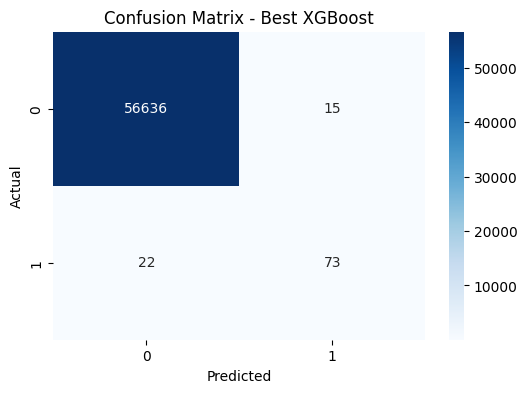

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Best XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Precision-Recall Curve for XGBoost

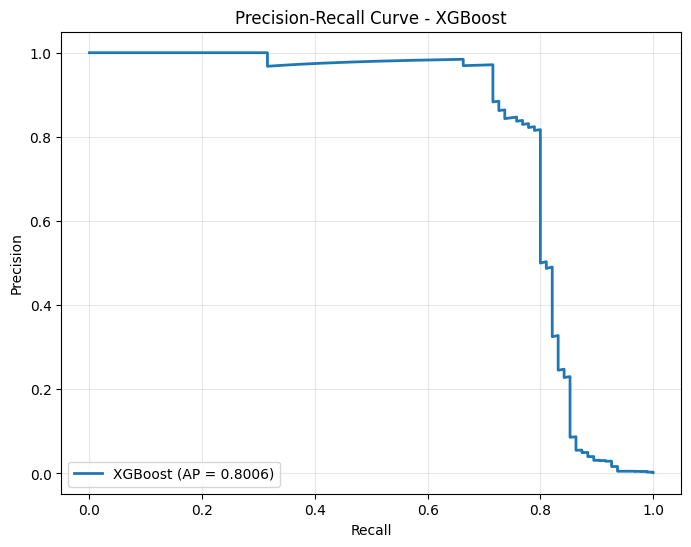

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Probabilities
xgb_probs = best_model.predict_proba(X_test)[:,1]

# Precision-Recall values
precision, recall, thresholds = precision_recall_curve(y_test, xgb_probs)

# Average Precision Score
ap_score = average_precision_score(y_test, xgb_probs)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"XGBoost (AP = {ap_score:.4f})"
)

plt.title("Precision-Recall Curve - XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

plt.show()

### Cross-Validation for XGBoost

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd
import seaborn as sns

# Stratified KFold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validation F1 scores
cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    scoring='f1',
    cv=skf,
    n_jobs=-1
)

# Print scores
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}")

print("\nMean F1:", cv_scores.mean())
print("Std:", cv_scores.std())

Fold 1: 0.9974
Fold 2: 0.9976
Fold 3: 0.9974
Fold 4: 0.9975
Fold 5: 0.9975

Mean F1: 0.9974655360715594
Std: 9.44074930192026e-05


### ROC Curve for XGBoost

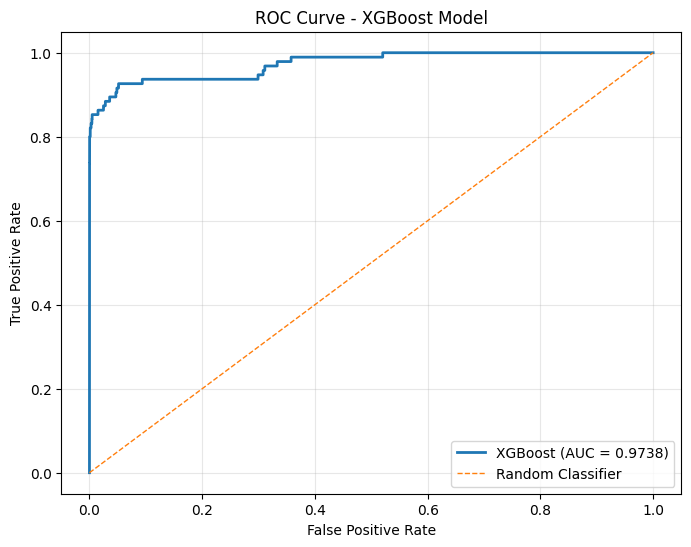

In [ ]:
# ROC Curve + AUC Score Graph

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities from best model
probs = best_model.predict_proba(X_test)[:,1]

# Calculate ROC points
fpr, tpr, thresholds = roc_curve(y_test, probs)

# Calculate AUC
auc_score = roc_auc_score(y_test, probs)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2, label=f"XGBoost (AUC = {auc_score:.4f})")
plt.plot([0,1], [0,1], linestyle='--', linewidth=1, label="Random Classifier")

plt.title("ROC Curve - XGBoost Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

## **RANDOM FOREST**

### Define Hyperparameter Distribution for Randomized Search

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, f1_score
import numpy as np
from scipy.stats import randint

param_dist = {
    "n_estimators": randint(50, 100),
    "max_depth": randint(4, 8),
    "min_samples_split": randint(2, 6),
    "min_samples_leaf": randint(1, 3),
    "max_features": ["sqrt", "log2"]
}

### Perform Randomized Search for Random Forest Hyperparameter Tuning

In [ ]:
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

### Optimize Prediction Threshold for Random Forest

In [ ]:
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,          # can increase to 40 if you want stronger
    scoring="f1",
    cv=2,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_rf = search.best_estimator_

print("Best Parameters:")
print(search.best_params_)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best Parameters:
{'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 68}


### Final Evaluation of the Best Random Forest Model

In [ ]:
probs_rf = best_rf.predict_proba(X_test)[:,1]
from sklearn.metrics import f1_score
import numpy as np

best_f1_rf = 0
best_threshold_rf = 0.50

for th in np.arange(0.30,0.91,0.05):

    preds = (probs_rf > th).astype(int)

    f1 = f1_score(y_test, preds)

    if f1 > best_f1_rf:
        best_f1_rf = f1
        best_threshold_rf = th

print("Best Threshold:", best_threshold_rf)
print("Best F1:", best_f1_rf)

Best Threshold: 0.8499999999999999
Best F1: 0.7953216374269005


### Random Forest Confusion Matrix

In [ ]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score
)

# Final predictions
final_preds_rf = (probs_rf > best_threshold_rf).astype(int)

print("===== RANDOM FOREST REPORT =====")

print(classification_report(
    y_test,
    final_preds_rf,
    digits=4
))

print("ROC AUC:", roc_auc_score(y_test, probs_rf))
print("Precision:", precision_score(y_test, final_preds_rf))
print("Recall:", recall_score(y_test, final_preds_rf))
print("F1:", f1_score(y_test, final_preds_rf))

===== RANDOM FOREST REPORT =====
              precision    recall  f1-score   support

           0     0.9995    0.9999    0.9997     56651
           1     0.8947    0.7158    0.7953        95

    accuracy                         0.9994     56746
   macro avg     0.9471    0.8578    0.8975     56746
weighted avg     0.9993    0.9994    0.9993     56746

ROC AUC: 0.9761412675392918
Precision: 0.8947368421052632
Recall: 0.7157894736842105
F1: 0.7953216374269005


### ROC Curve for Random Forest

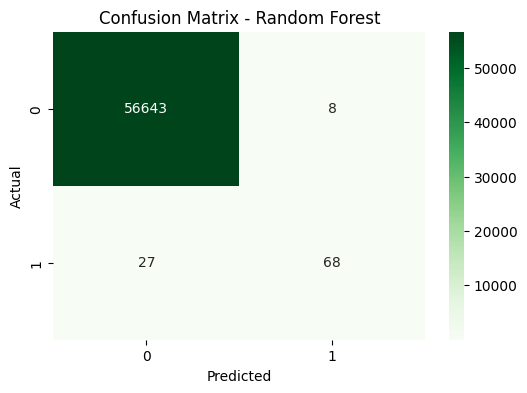

In [ ]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, final_preds_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Precision-Recall Curve for Random Forest

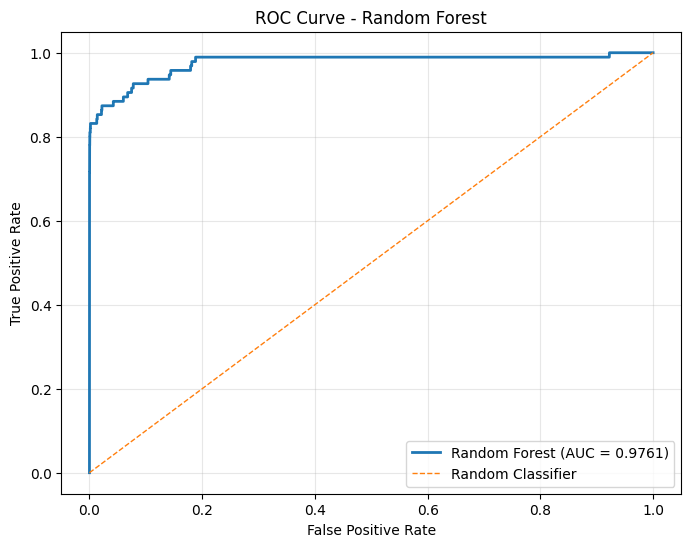

In [ ]:
# ==========================================================
# ROC CURVE + ROC-AUC
# ==========================================================

from sklearn.metrics import roc_curve

# ROC values
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, probs_rf)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, probs_rf):.4f})"
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=1,
    label='Random Classifier'
)

plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.show()

## **Random Forest + XGBoost**

### Generate Predictions for Hybrid Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
param_grid_rf = [100, 150]
param_grid_xgb = [
    {"n_estimators":100, "max_depth":3},
    {"n_estimators":200, "max_depth":4}
]

results_hybrid = []
best_hybrid = None
best_hybrid_score = 0

for rf_n in param_grid_rf:
    for xgb_p in param_grid_xgb:

        rf = RandomForestClassifier(n_estimators=rf_n)
        xgb = XGBClassifier(**xgb_p, eval_metric="logloss")

        hybrid = VotingClassifier(
            estimators=[('rf', rf), ('xgb', xgb)],
            voting='soft'
        )

        hybrid.fit(X_train, y_train)
        preds = hybrid.predict(X_test)

        f1 = f1_score(y_test, preds)

        results_hybrid.append([rf_n, xgb_p["n_estimators"], f1])

        if f1 > best_hybrid_score:
            best_hybrid_score = f1
            best_hybrid = hybrid

pd.DataFrame(results_hybrid, columns=["RF","XGB","F1"])

,RF,XGB,F1
0,100,100,0.732394
1,100,200,0.810811
2,150,100,0.725581
3,150,200,0.815217


### Classification Report for Hybrid Model

In [ ]:
# ==========================================================
# PREDICTIONS
# ==========================================================

# Prediction probabilities
probs_hybrid = best_hybrid.predict_proba(X_test)[:,1]

# Binary predictions
preds_hybrid = best_hybrid.predict(X_test)

### Confusion Matrix for Hybrid Model

In [ ]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

print("===== HYBRID MODEL REPORT =====\n")

print(
    classification_report(
        y_test,
        preds_hybrid,
        digits=4
    )
)

print("ROC AUC:", roc_auc_score(y_test, probs_hybrid))
print("Precision:", precision_score(y_test, preds_hybrid))
print("Recall:", recall_score(y_test, preds_hybrid))
print("F1 Score:", f1_score(y_test, preds_hybrid))

===== HYBRID MODEL REPORT =====

              precision    recall  f1-score   support

           0     0.9996    0.9998    0.9997     56651
           1     0.8427    0.7895    0.8152        95

    accuracy                         0.9994     56746
   macro avg     0.9212    0.8946    0.9075     56746
weighted avg     0.9994    0.9994    0.9994     56746

ROC AUC: 0.9760544943230436
Precision: 0.8426966292134831
Recall: 0.7894736842105263
F1 Score: 0.8152173913043478


### ROC Curve for Hybrid Model

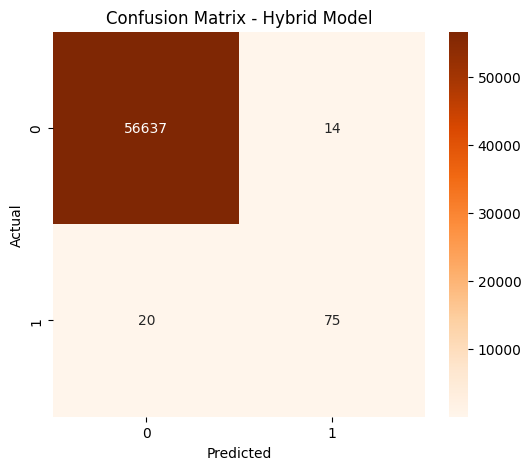

In [ ]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_hybrid = confusion_matrix(
    y_test,
    preds_hybrid
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_hybrid,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Confusion Matrix - Hybrid Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Precision-Recall Curve for Hybrid Model

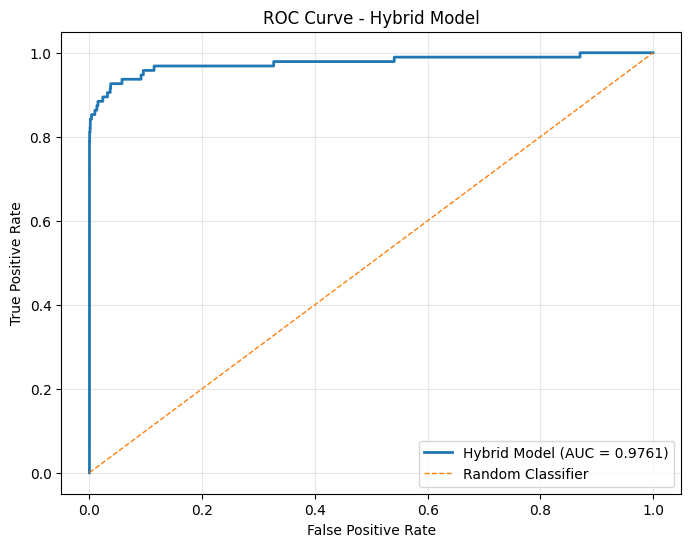

In [ ]:
# ==========================================================
# ROC CURVE + ROC-AUC
# ==========================================================

from sklearn.metrics import roc_curve

# ROC values
fpr_hybrid, tpr_hybrid, thresholds_hybrid = roc_curve(
    y_test,
    probs_hybrid
)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    fpr_hybrid,
    tpr_hybrid,
    linewidth=2,
    label=f"Hybrid Model (AUC = {roc_auc_score(y_test, probs_hybrid):.4f})"
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=1,
    label='Random Classifier'
)

plt.title("ROC Curve - Hybrid Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.show()

## **LSTM with XGBoost**

### Define LSTM Model Architecture

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

### Train the LSTM Model

In [ ]:


X_train_lstm = np.expand_dims(X_train, axis=1)
X_test_lstm = np.expand_dims(X_test, axis=1)

print("Train Shape:", X_train_lstm.shape)
print("Test Shape:", X_test_lstm.shape)

Train Shape: (453204, 1, 30)
Test Shape: (56746, 1, 30)


### Extract Features from LSTM and Train XGBoost

In [ ]:
input_layer = Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]))

x = LSTM(64, return_sequences=False)(input_layer)

x = Dropout(0.3)(x)

feature_layer = Dense(32, activation='relu', name='feature_layer')(x)

output_layer = Dense(1, activation='sigmoid')(feature_layer)

lstm_model = Model(inputs=input_layer, outputs=output_layer)

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 30)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,433 (103.25 KB)

 Trainable params: 26,433 (103.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = lstm_model.fit(
    X_train_lstm,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15
11331/11331 ━━━━━━━━━━━━━━━━━━━━ 49s 4ms/step - accuracy: 0.9894 - loss: 0.0301 - val_accuracy: 1.0000 - val_loss: 0.0041
Epoch 2/15
11331/11331 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - accuracy: 0.9978 - loss: 0.0075 - val_accuracy: 0.9999 - val_loss: 0.0022
Epoch 3/15
11331/11331 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - accuracy: 0.9987 - loss: 0.0049 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 4/15
11331/11331 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - accuracy: 0.9990 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 3.8095e-04
Epoch 5/15
11331/11331 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - accuracy: 0.9991 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 8.5884e-04
Epoch 6/15
11331/11331 ━━━━━━━━━━━━━━━━━━━━ 71s 6ms/step - accuracy: 0.9993 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 3.4215e-04
Epoch 7/15
11331/11331 ━━━━━━━━━━━━━━━━━━━━ 51s 4ms/step - accuracy: 0.9993 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 7.3821e-04
Epoch 8/15
11331/11331 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/s

### Generate Predictions from Hybrid LSTM-XGBoost

In [ ]:
feature_extractor = Model(
    inputs=lstm_model.input,
    outputs=lstm_model.get_layer("feature_layer").output
)

X_train_features = feature_extractor.predict(X_train_lstm)
X_test_features = feature_extractor.predict(X_test_lstm)

print(X_train_features.shape)
print(X_test_features.shape)

14163/14163 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
(453204, 32)
(56746, 32)


### Classification Report for Hybrid LSTM-XGBoost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_features, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.08, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_probs = xgb_model.predict_proba(X_test_features)[:, 1]

y_pred = (y_probs > 0.5).astype(int)

### Confusion Matrix for Hybrid LSTM-XGBoost

In [ ]:
print("\nCLASSIFICATION REPORT\n")

print(classification_report(y_test, y_pred, digits=4))


CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0     0.9996    0.9997    0.9996     56651
           1     0.7957    0.7789    0.7872        95

    accuracy                         0.9993     56746
   macro avg     0.8977    0.8893    0.8934     56746
weighted avg     0.9993    0.9993    0.9993     56746



### ROC-AUC Curve for Hybrid LSTM-XGBoost

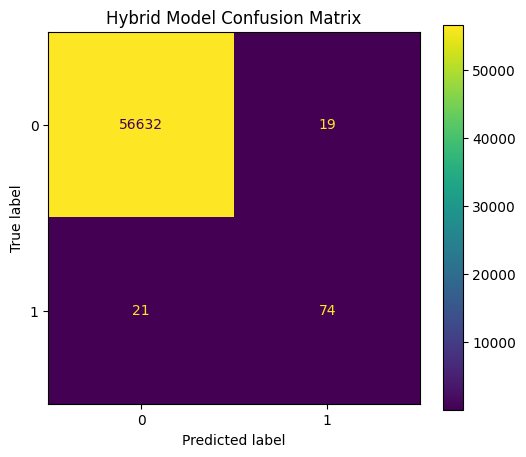

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(ax=ax)

plt.title("Hybrid Model Confusion Matrix")
plt.show()

### Precision-Recall Curve for Hybrid LSTM-XGBoost

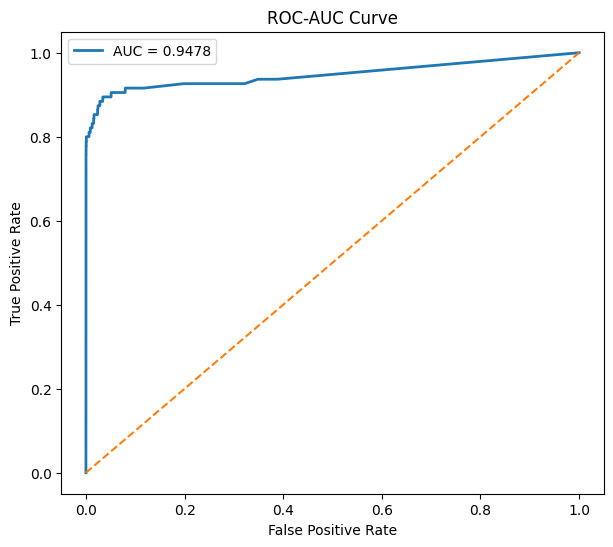

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, linewidth=2,
         label=f'AUC = {roc_auc:.4f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")

plt.legend()

plt.show()

## **NEURAL NETWORK**

This section implements an optimized Neural Network (Multi-Layer Perceptron) model for fraud detection. It uses SMOTE for handling class imbalance and early stopping during training for efficiency.

### Data Preparation (Scaling and SMOTE) for Neural Network

In [ ]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

### Define Neural Network Architecture

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler # Changed from StandardScaler

# Ensure X and y are defined from earlier data loading/preprocessing if running this cell independently.
# Splitting the original data for the Neural Network section
X_train_ae, X_test_ae, y_train_ae, y_test_ae = train_test_split(
    X, y,
    test_size=0.2, # Matching the split size from the Autoencoder section
    stratify=y,
    random_state=42
)

# Scale the data for the Neural Network using RobustScaler
scaler_ae = RobustScaler() # Using RobustScaler as per previous preprocessing
X_train_scaled_ae = scaler_ae.fit_transform(X_train_ae)
X_test_scaled_ae = scaler_ae.transform(X_test_ae)

smote_nn = SMOTE(
    sampling_strategy='auto',
    random_state=42
)

X_train_nn_resampled, y_train_nn_resampled = smote_nn.fit_resample(
    X_train_scaled_ae,
    y_train_ae
)

print("Resampled Train Shape:", X_train_nn_resampled.shape)
print("Test Shape:", X_test_scaled_ae.shape)

Resampled Train Shape: (453204, 30)
Test Shape: (56746, 30)


### Compile Neural Network Model

In [ ]:
# ==========================================================
# NEURAL NETWORK ARCHITECTURE
# ==========================================================

input_dim = X_train_nn_resampled.shape[1]

model_nn = Sequential([

    Dense(
        128,
        activation='relu',
        input_shape=(input_dim,)
    ),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

print("Neural Network Architecture:\n")

model_nn.summary()

Neural Network Architecture:



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

### Define Early Stopping Callback

In [ ]:
# ==========================================================
# COMPILE MODEL
# ==========================================================

model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

print("Model compiled successfully.")


Model compiled successfully.


### Train the Neural Network Model

In [ ]:
# ==========================================================
# EARLY STOPPING
# ==========================================================

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,                 # lower patience = faster
    restore_best_weights=True,
    verbose=1
)

### Generate Predictions from Neural Network

In [ ]:
# ==========================================================
# TRAIN MODEL
# ==========================================================

print("Training Neural Network...\n")

start_time_nn = time.time()

history_nn = model_nn.fit(

    X_train_nn_resampled,
    y_train_nn_resampled,

    epochs=40,                 # lower epochs for speed
    batch_size=256,

    validation_split=0.2,

    callbacks=[early_stopping],

    verbose=1
)

end_time_nn = time.time()

print(f"\nTraining completed in {end_time_nn - start_time_nn:.2f} seconds.")

Training Neural Network...

Epoch 1/40
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9793 - auc: 0.9977 - loss: 0.0564 - precision: 0.9752 - recall: 0.9696 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0046 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 2/40
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9973 - auc: 0.9997 - loss: 0.0108 - precision: 0.9945 - recall: 0.9982 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0016 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 3/40
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9984 - auc: 0.9998 - loss: 0.0067 - precision: 0.9967 - recall: 0.9991 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 8.9049e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 4/40
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9988 - auc: 0.9998 - loss: 0.0053 - precision: 0.9975 - recall: 0.9993 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0047 - val_precision: 1.

### Evaluate Neural Network Model

In [ ]:
# ==========================================================
# PREDICTIONS
# ==========================================================

# Predict probabilities
predictions_nn_proba = model_nn.predict(
    X_test_scaled_ae
).flatten()

# Convert to binary predictions
predictions_nn = (
    predictions_nn_proba > 0.5
).astype(int)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


### Confusion Matrix for Neural Network

In [ ]:
# ==========================================================
# MODEL EVALUATION
# ==========================================================

f1_nn = f1_score(
    y_test_ae,
    predictions_nn
)

roc_auc_nn = roc_auc_score(
    y_test_ae,
    predictions_nn_proba
)

print("===== NEURAL NETWORK EVALUATION =====\n")

print(f"F1 Score: {f1_nn:.4f}")
print(f"ROC AUC Score: {roc_auc_nn:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_ae,
        predictions_nn,
        digits=4
    )
)

===== NEURAL NETWORK EVALUATION =====

F1 Score: 0.7246
ROC AUC Score: 0.9514

Classification Report:

              precision    recall  f1-score   support

           0     0.9996    0.9993    0.9995     56651
           1     0.6696    0.7895    0.7246        95

    accuracy                         0.9990     56746
   macro avg     0.8346    0.8944    0.8621     56746
weighted avg     0.9991    0.9990    0.9990     56746



### ROC Curve for Neural Network

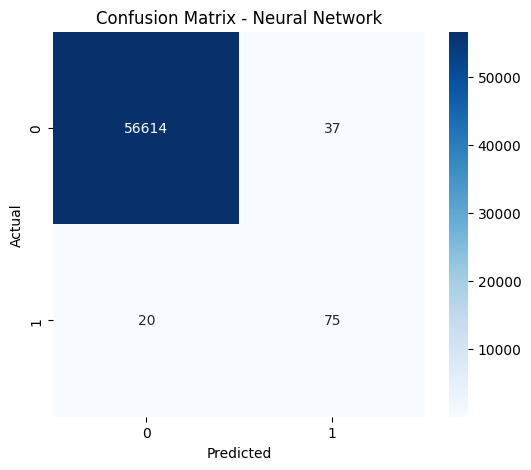

In [ ]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm_nn = confusion_matrix(
    y_test_ae,
    predictions_nn
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nn,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Precision-Recall Curve for Neural Network

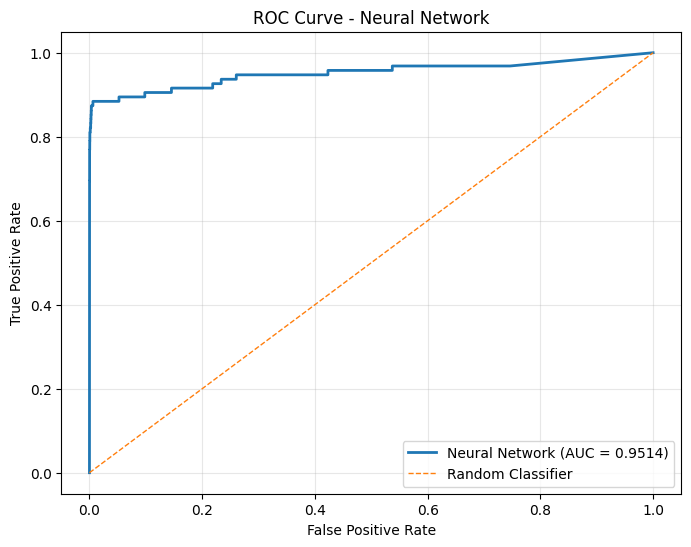

In [ ]:
# ==========================================================
# ROC CURVE + ROC-AUC
# ==========================================================

from sklearn.metrics import roc_curve

# ROC values
fpr_nn, tpr_nn, thresholds_nn = roc_curve(
    y_test_ae,
    predictions_nn_proba
)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    fpr_nn,
    tpr_nn,
    linewidth=2,
    label=f"Neural Network (AUC = {roc_auc_nn:.4f})"
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=1,
    label='Random Classifier'
)

plt.title("ROC Curve - Neural Network")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.show()

### Model Performance Comparison

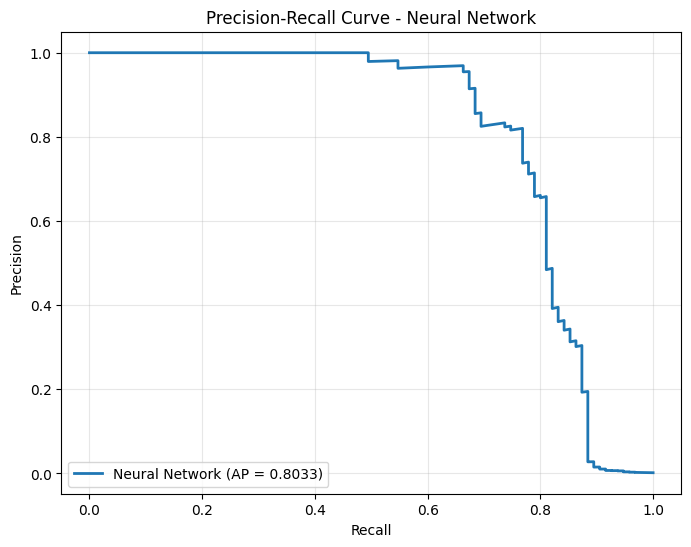

In [ ]:
# ==========================================================
# PRECISION - RECALL CURVE
# ==========================================================

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

# Precision-Recall values
precision_nn, recall_nn, _ = precision_recall_curve(
    y_test_ae,
    predictions_nn_proba
)

# Average Precision
ap_nn = average_precision_score(
    y_test_ae,
    predictions_nn_proba
)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    recall_nn,
    precision_nn,
    linewidth=2,
    label=f"Neural Network (AP = {ap_nn:.4f})"
)

plt.title("Precision-Recall Curve - Neural Network")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

plt.show()